# Capstone Part 3 – Machine Learning and AI
## Intelligent Mobility Solution

This notebook develops machine learning and AI solutions using the Metro Interstate Traffic Volume dataset.

Because no accident dataset was provided, a proxy accident-risk label is created using congestion level and severe or low-visibility weather conditions, as specified in the capstone instructions.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/Metro_Interstate_Traffic_Volume.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2/10/2012 9:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2/10/2012 10:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2/10/2012 11:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2/10/2012 12:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2/10/2012 13:00,4918


In [3]:
# Basic data preparation for Part 3

# Convert date_time
df["date_time"] = pd.to_datetime(
    df["date_time"],
    format="mixed",
    dayfirst=True
)

# Preserve the original holiday information
# A named holiday appears on one record of the holiday date
holiday_dates = (
    df.loc[
        df["holiday"].notna() & (df["holiday"] != "None"),
        "date_time"
    ]
    .dt.normalize()
    .unique()
)

# Mark every timestamp occurring on a holiday date

Basic feature engineering completed.


,date_time,holiday,is_holiday
0,2012-10-02 09:00:00,None,1
1,2012-10-02 10:00:00,None,1
2,2012-10-02 11:00:00,None,1
3,2012-10-02 12:00:00,None,1
4,2012-10-02 13:00:00,None,1
5,2012-10-02 14:00:00,None,1
6,2012-10-02 15:00:00,None,1
7,2012-10-02 16:00:00,None,1
8,2012-10-02 17:00:00,None,1
9,2012-10-02 18:00:00,None,1


In [3]:
print("First 10 holiday dates:")
print(holiday_dates[:10])

print("\nOriginal named holiday rows:")
df[df["holiday"] != "None"][["date_time", "holiday"]].head(10)

First 10 holiday dates:
<DatetimeArray>
['2012-10-08 00:00:00', '2012-11-12 00:00:00', '2012-11-22 00:00:00',
 '2012-12-25 00:00:00', '2013-01-01 00:00:00', '2013-02-18 00:00:00',
 '2013-05-27 00:00:00', '2013-07-04 00:00:00', '2013-08-22 00:00:00',
 '2013-09-02 00:00:00']
Length: 10, dtype: datetime64[ns]

Original named holiday rows:


,date_time,holiday
0,2012-10-02 09:00:00,NaN
1,2012-10-02 10:00:00,NaN
2,2012-10-02 11:00:00,NaN
3,2012-10-02 12:00:00,NaN
4,2012-10-02 13:00:00,NaN
5,2012-10-02 14:00:00,NaN
6,2012-10-02 15:00:00,NaN
7,2012-10-02 16:00:00,NaN
8,2012-10-02 17:00:00,NaN
9,2012-10-02 18:00:00,NaN


In [4]:
# Re-create holiday indicator correctly

# Find only rows that contain an actual holiday name
holiday_dates = (
    df.loc[df["holiday"].notna(), "date_time"]
      .dt.normalize()
      .unique()
)

# Mark every hour belonging to those holiday dates
df["is_holiday"] = (
    df["date_time"].dt.normalize().isin(holiday_dates)
).astype(int)

# Check beginning of dataset
df[["date_time", "holiday", "is_holiday"]].head(15)

,date_time,holiday,is_holiday
0,2012-10-02 09:00:00,NaN,0
1,2012-10-02 10:00:00,NaN,0
2,2012-10-02 11:00:00,NaN,0
3,2012-10-02 12:00:00,NaN,0
4,2012-10-02 13:00:00,NaN,0
5,2012-10-02 14:00:00,NaN,0
6,2012-10-02 15:00:00,NaN,0
7,2012-10-02 16:00:00,NaN,0
8,2012-10-02 17:00:00,NaN,0
9,2012-10-02 18:00:00,NaN,0


In [5]:
df[
    df["date_time"].dt.date == pd.Timestamp("2012-10-08").date()
][["date_time", "holiday", "is_holiday"]]

,date_time,holiday,is_holiday
126,2012-10-08 00:00:00,Columbus Day,1
127,2012-10-08 01:00:00,NaN,1
128,2012-10-08 02:00:00,NaN,1
129,2012-10-08 03:00:00,NaN,1
130,2012-10-08 04:00:00,NaN,1
131,2012-10-08 05:00:00,NaN,1
132,2012-10-08 06:00:00,NaN,1
133,2012-10-08 07:00:00,NaN,1
134,2012-10-08 08:00:00,NaN,1
135,2012-10-08 09:00:00,NaN,1


## Task 1: Supervised Machine Learning

### Creating Congestion Categories

Traffic volume is divided into four congestion categories using quartiles of `traffic_volume`:

- Low: ≤ Q1
- Medium: > Q1 to ≤ Q2
- High: > Q2 to ≤ Q3
- Severe: > Q3

The quartile thresholds divide the traffic-volume observations into approximately equal-sized groups.

In [5]:
q1, q2, q3 = df["traffic_volume"].quantile([0.25, 0.5, 0.75]).values

def bucket(v):
    if v <= q1:
        return "Low"
    elif v <= q2:
        return "Medium"
    elif v <= q3:
        return "High"
    return "Severe"

df["congestion_category"] = df["traffic_volume"].apply(bucket)

print("Traffic volume quartiles:")
print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)

print("\nCongestion category counts:")
print(df["congestion_category"].value_counts())

Traffic volume quartiles:
Q1: 1193.0
Q2: 3380.0
Q3: 4933.0

Congestion category counts:
congestion_category
High      12058
Medium    12053
Low       12053
Severe    12040
Name: count, dtype: int64


In [7]:
print("Weather main categories:")
print(df["weather_main"].value_counts())

print("\nWeather descriptions:")
print(df["weather_description"].value_counts())

Weather main categories:
weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

Weather descriptions:
weather_description
sky is clear                           11665
mist                                    5950
overcast clouds                         5081
broken clouds                           4666
scattered clouds                        3461
light rain                              3372
few clouds                              1956
light snow                              1946
Sky is Clear                            1726
moderate rain                           1664
haze                                    1360
light intensity drizzle                 1100
fog                                      912
proximity thunderstorm                   673
drizzle              

### Creating Severe Weather and Low-Visibility Indicators

The proxy accident-risk label requires identification of severe or low-visibility weather conditions.

Severe weather conditions are identified from the `weather_main` categories, while low-visibility conditions are identified from weather categories associated with reduced visibility.

In [6]:
# Define severe and low-visibility weather categories

SEVERE_WEATHER = ["Thunderstorm", "Squall", "Snow"]
LOW_VISIBILITY_WEATHER = ["Mist", "Fog", "Haze", "Smoke"]

# Create low-visibility indicator
df["is_low_visibility"] = (
    df["weather_main"].isin(LOW_VISIBILITY_WEATHER)
).astype(int)

# Display counts
print("Severe weather observations:")
print(df["weather_main"].isin(SEVERE_WEATHER).value_counts())

print("\nLow-visibility observations:")
print(df["is_low_visibility"].value_counts())

Severe weather observations:
weather_main
False    44290
True      3914
Name: count, dtype: int64

Low-visibility observations:
is_low_visibility
0    39962
1     8242
Name: count, dtype: int64


### Creating the Proxy Accident-Risk Label

Because no accident dataset was provided, a proxy accident-risk label is created as specified in the capstone instructions. An observation is classified as high risk when High or Severe congestion occurs together with severe or low-visibility weather conditions.

In [7]:
# Identify High or Severe congestion
high_congestion = df["congestion_category"].isin(["High", "Severe"])

# Identify risky weather
risky_weather = (
    df["weather_main"].isin(SEVERE_WEATHER)
    | (df["is_low_visibility"] == 1)
)

# Create proxy accident-risk label
df["high_risk"] = (high_congestion & risky_weather).astype(int)

# Display class distribution
print("Proxy accident-risk distribution:")
print(df["high_risk"].value_counts())

print("\nPercentage distribution:")
print(df["high_risk"].value_counts(normalize=True) * 100)

Proxy accident-risk distribution:
high_risk
0    42768
1     5436
Name: count, dtype: int64

Percentage distribution:
high_risk
0    88.722928
1    11.277072
Name: proportion, dtype: float64


### Proxy Accident-Risk Class Distribution

The proxy high-risk class represents approximately 11.3% of observations, while 88.7% are classified as non-high-risk. Therefore, the classification target is imbalanced. Model performance will be assessed using precision, recall, F1-score and ROC AUC in addition to accuracy.

### Cyclical Encoding of Time Features

Hour of day and day of week are cyclical variables. Sine and cosine transformations are used so that neighbouring values across the cycle, such as 23:00 and 00:00, are represented as being close to each other.

In [10]:
# Cyclical encoding of hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Cyclical encoding of day of week
df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Check new features
df[
    ["date_time", "hour", "hour_sin", "hour_cos",
     "day_of_week", "day_sin", "day_cos"]
].head()

KeyError: 'hour'

In [8]:
## Create time features and cyclical encodings

# Re-create basic time features from date_time
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["month"] = df["date_time"].dt.month

# Cyclical encoding of hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Cyclical encoding of day of week
df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Check new features
df[
    ["date_time", "hour", "hour_sin", "hour_cos",
     "day_of_week", "day_sin", "day_cos"]
].head()

,date_time,hour,hour_sin,hour_cos,day_of_week,day_sin,day_cos
0,2012-10-02 09:00:00,9,7.071068e-01,-0.707107,1,0.781831,0.62349
1,2012-10-02 10:00:00,10,5.000000e-01,-0.866025,1,0.781831,0.62349
2,2012-10-02 11:00:00,11,2.588190e-01,-0.965926,1,0.781831,0.62349
3,2012-10-02 12:00:00,12,1.224647e-16,-1.000000,1,0.781831,0.62349
4,2012-10-02 13:00:00,13,-2.588190e-01,-0.965926,1,0.781831,0.62349


In [9]:
## Encode categorical weather information

# One-hot encode weather_main
weather_encoded = pd.get_dummies(
    df["weather_main"],
    prefix="weather",
    dtype=int
)

# Add encoded weather columns to the dataframe
df = pd.concat([df, weather_encoded], axis=1)

# Display the new weather encoding columns
weather_columns = weather_encoded.columns.tolist()

print("Weather encoding columns:")
print(weather_columns)

df[["weather_main"] + weather_columns].head()

Weather encoding columns:
['weather_Clear', 'weather_Clouds', 'weather_Drizzle', 'weather_Fog', 'weather_Haze', 'weather_Mist', 'weather_Rain', 'weather_Smoke', 'weather_Snow', 'weather_Squall', 'weather_Thunderstorm']


,weather_main,weather_Clear,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm
0,Clouds,0,1,0,0,0,0,0,0,0,0,0
1,Clouds,0,1,0,0,0,0,0,0,0,0,0
2,Clouds,0,1,0,0,0,0,0,0,0,0,0
3,Clouds,0,1,0,0,0,0,0,0,0,0,0
4,Clouds,0,1,0,0,0,0,0,0,0,0,0


In [10]:
## Define the common feature set

base_feature_columns = [
    # Time-based features
    "hour",
    "day_of_week",
    "month",

    # Cyclical time encodings
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",

    # Holiday flag
    "is_holiday",

    # Additional weather features
    "is_low_visibility",
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all"
]

# Add one-hot encoded weather categories
feature_columns = base_feature_columns + weather_columns

print("Common feature set:")
print(feature_columns)

print("\nNumber of features:", len(feature_columns))

Common feature set:
['hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'is_holiday', 'is_low_visibility', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_Clear', 'weather_Clouds', 'weather_Drizzle', 'weather_Fog', 'weather_Haze', 'weather_Mist', 'weather_Rain', 'weather_Smoke', 'weather_Snow', 'weather_Squall', 'weather_Thunderstorm']

Number of features: 24


Classification Model: Predicting Proxy Accident Risk
Two classification algorithms are compared: Logistic Regression as a baseline model and Random Forest as a tree-based ensemble model. The target variable is high_risk.

In [24]:
## Prepare data for classification

from sklearn.model_selection import train_test_split

# Features and classification target
X_class = df[feature_columns].copy()
y_class = df["high_risk"].copy()

# Check for missing values
print("Missing values in classification features:")
print(X_class.isnull().sum())

print("\nTarget distribution:")
print(y_class.value_counts())

Missing values in classification features:
hour                    0
day_of_week             0
month                   0
hour_sin                0
hour_cos                0
day_sin                 0
day_cos                 0
is_holiday              0
is_low_visibility       0
temp                    0
rain_1h                 0
snow_1h                 0
clouds_all              0
weather_Clear           0
weather_Clouds          0
weather_Drizzle         0
weather_Fog             0
weather_Haze            0
weather_Mist            0
weather_Rain            0
weather_Smoke           0
weather_Snow            0
weather_Squall          0
weather_Thunderstorm    0
dtype: int64

Target distribution:
high_risk
0    42768
1     5436
Name: count, dtype: int64


Train-Test Split
The dataset is divided into training and testing sets using an 80:20 split. Stratification is used to preserve the proportion of high-risk and non-high-risk observations in both sets.

In [25]:
## Split classification data into training and test sets

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training observations:", len(X_train_class))
print("Testing observations:", len(X_test_class))

print("\nTraining target distribution (%):")
print(y_train_class.value_counts(normalize=True) * 100)

print("\nTesting target distribution (%):")
print(y_test_class.value_counts(normalize=True) * 100)

Training observations: 38563
Testing observations: 9641

Training target distribution (%):
high_risk
0    88.72235
1    11.27765
Name: proportion, dtype: float64

Testing target distribution (%):
high_risk
0    88.725236
1    11.274764
Name: proportion, dtype: float64


### Logistic Regression

Logistic Regression is used as a baseline classification model to predict whether an observation is classified as high risk.

In [26]:
## Train Logistic Regression classification model

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Scale the features
scaler_class = StandardScaler()

X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

# Create and train Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_class_scaled, y_train_class)

# Make predictions
y_pred_log = log_reg.predict(X_test_class_scaled)
y_prob_log = log_reg.predict_proba(X_test_class_scaled)[:, 1]

# Evaluate model
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy:", accuracy_score(y_test_class, y_pred_log))
print("Precision:", precision_score(y_test_class, y_pred_log))
print("Recall:", recall_score(y_test_class, y_pred_log))
print("F1-score:", f1_score(y_test_class, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test_class, y_prob_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_log))

Logistic Regression Results
---------------------------
Accuracy: 0.9780105798153719
Precision: 0.9024839006439742
Recall: 0.9024839006439742
F1-score: 0.9024839006439742
ROC AUC: 0.9946578896254952

Confusion Matrix:
[[8448  106]
 [ 106  981]]


### Random Forest Classification

A Random Forest classifier is trained using the same feature set and train-test split to allow direct comparison with Logistic Regression.

In [27]:
## Train Random Forest classification model

from sklearn.ensemble import RandomForestClassifier

# Create and train Random Forest model
rf_class = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_class.fit(X_train_class, y_train_class)

# Make predictions
y_pred_rf = rf_class.predict(X_test_class)
y_prob_rf = rf_class.predict_proba(X_test_class)[:, 1]

# Evaluate model
print("Random Forest Classification Results")
print("------------------------------------")
print("Accuracy:", accuracy_score(y_test_class, y_pred_rf))
print("Precision:", precision_score(y_test_class, y_pred_rf))
print("Recall:", recall_score(y_test_class, y_pred_rf))
print("F1-score:", f1_score(y_test_class, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test_class, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_rf))

Random Forest Classification Results
------------------------------------
Accuracy: 0.9892127372679183
Precision: 0.9456029011786038
Recall: 0.9595216191352346
F1-score: 0.9525114155251142
ROC AUC: 0.9975811442174065

Confusion Matrix:
[[8494   60]
 [  44 1043]]


In [28]:
## Compare classification model performance

import pandas as pd

classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test_class, y_pred_log),
        accuracy_score(y_test_class, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test_class, y_pred_log),
        precision_score(y_test_class, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test_class, y_pred_log),
        recall_score(y_test_class, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test_class, y_pred_log),
        f1_score(y_test_class, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test_class, y_prob_log),
        roc_auc_score(y_test_class, y_prob_rf)
    ]
})

classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Logistic Regression,0.978,0.902,0.902,0.902,0.995
1,Random Forest,0.989,0.946,0.960,0.953,0.998


In [29]:
## Compare classification model performance

# Confusion matrix values
tn_log, fp_log, fn_log, tp_log = confusion_matrix(
    y_test_class, y_pred_log
).ravel()

tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(
    y_test_class, y_pred_rf
).ravel()

classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],

    "Accuracy": [
        accuracy_score(y_test_class, y_pred_log),
        accuracy_score(y_test_class, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test_class, y_pred_log),
        precision_score(y_test_class, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test_class, y_pred_log),
        recall_score(y_test_class, y_pred_rf)
    ],

    "F1-score": [
        f1_score(y_test_class, y_pred_log),
        f1_score(y_test_class, y_pred_rf)
    ],

    "ROC AUC": [
        roc_auc_score(y_test_class, y_prob_log),
        roc_auc_score(y_test_class, y_prob_rf)
    ],

    "True Negative": [tn_log, tn_rf],
    "False Positive": [fp_log, fp_rf],
    "False Negative": [fn_log, fn_rf],
    "True Positive": [tp_log, tp_rf]

})

classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC AUC,True Negative,False Positive,False Negative,True Positive
0,Logistic Regression,0.978,0.902,0.902,0.902,0.995,8448,106,106,981
1,Random Forest,0.989,0.946,0.960,0.953,0.998,8494,60,44,1043


### Regression Models: Predicting Traffic Volume

Two regression algorithms are compared to predict `traffic_volume`: Linear Regression as a baseline model and Random Forest Regression as a tree-based ensemble model. The same common engineered feature set is used as for the classification task.

In [11]:
## Prepare data for traffic-volume regression

# Use the same common feature set
X_reg = df[feature_columns].copy()

# Regression target
y_reg = df["traffic_volume"].copy()

# Check the regression data
print("Regression feature shape:", X_reg.shape)

print("\nMissing values in regression features:")
print(X_reg.isnull().sum())

print("\nTraffic volume summary:")
print(y_reg.describe())

Regression feature shape: (48204, 24)

Missing values in regression features:
hour                    0
day_of_week             0
month                   0
hour_sin                0
hour_cos                0
day_sin                 0
day_cos                 0
is_holiday              0
is_low_visibility       0
temp                    0
rain_1h                 0
snow_1h                 0
clouds_all              0
weather_Clear           0
weather_Clouds          0
weather_Drizzle         0
weather_Fog             0
weather_Haze            0
weather_Mist            0
weather_Rain            0
weather_Smoke           0
weather_Snow            0
weather_Squall          0
weather_Thunderstorm    0
dtype: int64

Traffic volume summary:
count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64


In [12]:
## Split regression data into training and test sets
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train_reg))
print("Testing observations:", len(X_test_reg))

print("\nTraining feature shape:", X_train_reg.shape)
print("Testing feature shape:", X_test_reg.shape)

Training observations: 38563
Testing observations: 9641

Training feature shape: (38563, 24)
Testing feature shape: (9641, 24)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create and train model
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_lin_reg = lin_reg.predict(X_test_reg)

# Evaluate model
mae_lin = mean_absolute_error(y_test_reg, y_pred_lin_reg)
rmse_lin = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin_reg))
r2_lin = r2_score(y_test_reg, y_pred_lin_reg)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae_lin)
print("RMSE:", rmse_lin)
print("R²:", r2_lin)

Linear Regression Results
-------------------------
MAE: 812.7353210830257
RMSE: 1035.3601626124223
R²: 0.7288562059279065


In [27]:
## Train and evaluate Random Forest Regression model

from sklearn.ensemble import RandomForestRegressor

# Create and train model
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_rf_reg = rf_reg.predict(X_test_reg)

# Evaluate model
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf_reg)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Regression Results
--------------------------------
MAE: 225.3878487832224
RMSE: 378.74913257651843
R²: 0.9637155903770841


In [34]:
## Compare regression model performance

regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lin, mae_rf],
    "RMSE": [rmse_lin, rmse_rf],
    "R²": [r2_lin, r2_rf]
})

regression_results.round(3)

,Model,MAE,RMSE,R²
0,Linear Regression,812.735,1035.360,0.729
1,Random Forest,225.390,378.755,0.964


### Task 1 Summary and Interpretation

Both classification and regression models were developed using the same engineered feature set containing time-based variables, weather encodings, a holiday flag, and cyclical encodings of hour and day of the week.

For classification, Random Forest outperformed Logistic Regression overall. Random Forest achieved higher accuracy, recall, F1-score and ROC AUC, while Logistic Regression had slightly higher precision. In particular, Random Forest identified a greater proportion of high-risk observations and produced fewer false negatives.

The very high classification performance should, however, be interpreted cautiously. The high-risk target is a proxy constructed partly from severe or low-visibility weather conditions, while weather variables are also included among the model predictors. This overlap may introduce target leakage and inflate apparent predictive performance. The classification model therefore predicts the defined proxy risk condition rather than actual accident occurrence.

For regression, Random Forest substantially outperformed Linear Regression. Linear Regression achieved an MAE of approximately 813 vehicles and an R² of 0.729, while Random Forest reduced the MAE to approximately 225 vehicles and increased R² to 0.964. This suggests that traffic volume has important non-linear relationships with time, weather and other predictors that are better captured by the tree-based ensemble model.

## Task 2: Unsupervised Machine Learning

### K-means Clustering of Traffic Conditions

K-means clustering is used to identify naturally occurring groups of traffic conditions without using a predefined target label. The clustering uses hour of day, weather severity and traffic volume.

In [35]:
## Prepare features for K-means clustering

# Create weather severity score
weather_severity_map = {
    "Clear": 0,
    "Clouds": 0,
    "Drizzle": 1,
    "Mist": 1,
    "Fog": 1,
    "Haze": 1,
    "Smoke": 1,
    "Rain": 2,
    "Snow": 2,
    "Thunderstorm": 2,
    "Squall": 2
}

df["weather_severity"] = df["weather_main"].map(weather_severity_map)

# Select clustering features
cluster_features = [
    "hour",
    "weather_severity",
    "traffic_volume"
]

X_cluster = df[cluster_features].copy()

print("Clustering features:")
print(cluster_features)

print("\nMissing values:")
print(X_cluster.isnull().sum())

X_cluster.head()

Clustering features:
['hour', 'weather_severity', 'traffic_volume']

Missing values:
hour                0
weather_severity    0
traffic_volume      0
dtype: int64


,hour,weather_severity,traffic_volume
0,9,0,5545
1,10,0,4516
2,11,0,4767
3,12,0,5026
4,13,0,4918


In [36]:
## Scale clustering features and test number of clusters

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Scale features so each contributes fairly to K-means
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Test different numbers of clusters
k_values = range(2, 7)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster_scaled, labels)
    )

# Display results
k_results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

k_results.round(3)

/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,Inertia,Silhouette Score
0,2,87933.899,0.415
1,3,58169.364,0.435
2,4,42179.875,0.453
3,5,31478.168,0.475
4,6,24341.604,0.491


In [38]:
## Scale clustering features and test number of clusters

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Scale features so each contributes fairly to K-means
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Test different numbers of clusters
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster_scaled, labels)
    )

# Display results
k_results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

k_results.round(3)

,k,Inertia,Silhouette Score
0,2,87933.899,0.415
1,3,58169.364,0.435
2,4,42179.875,0.453
3,5,31478.168,0.475
4,6,24341.604,0.491
5,7,20738.424,0.495
6,8,18096.519,0.466
7,9,15578.049,0.477
8,10,13986.451,0.484


In [39]:
## Fit final K-means model with 7 clusters

kmeans_final = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans_final.fit_predict(X_cluster_scaled)

# Summarise each cluster
cluster_summary = df.groupby("cluster").agg(
    observations=("cluster", "size"),
    mean_hour=("hour", "mean"),
    mean_weather_severity=("weather_severity", "mean"),
    mean_traffic_volume=("traffic_volume", "mean")
)

cluster_summary.round(2)

,observations,mean_hour,mean_weather_severity,mean_traffic_volume
cluster,,,,
0,13654,12.40,0.00,5097.88
1,4620,12.15,2.00,4945.17
2,6472,3.25,1.43,919.52
3,7847,3.13,0.00,937.87
4,7054,20.63,0.00,2668.83
5,3960,20.71,1.55,2392.77
6,4597,11.05,1.00,5018.76


### K-means Cluster Interpretation

Seven clusters were selected because k=7 produced the highest silhouette score (0.495) among the tested values from k=2 to k=10. The score indicates moderate rather than strong cluster separation.

The clusters reveal clear combinations of time of day, weather severity and traffic volume. High-volume daytime traffic was separated into mild, moderate and severe weather conditions. Early-morning traffic had substantially lower traffic volumes and was separated according to mild versus adverse weather. Evening traffic formed moderate-volume clusters that were also differentiated by weather severity.

Overall, the clustering suggests that time of day and traffic volume form the main traffic patterns, while weather conditions further distinguish traffic states within similar periods of the day.

In [40]:
## Prepare categorical data for association rule mining

# Create time-of-day categories
df["time_of_day"] = pd.cut(
    df["hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["Night", "Morning", "Afternoon", "Evening", "Late_Night"]
)

# Create weekday/weekend category
df["weekday_type"] = df["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

# Use existing weather category and congestion category
association_data = df[
    ["time_of_day", "weekday_type", "weather_main", "congestion_category"]
].copy()

print("Association-rule variables:")
print(association_data.head())

print("\nTime-of-day counts:")
print(association_data["time_of_day"].value_counts())

KeyError: 'is_weekend'

In [41]:
## Prepare categorical data for association rule mining

# Re-create weekend indicator
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Create time-of-day categories
df["time_of_day"] = pd.cut(
    df["hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["Night", "Morning", "Afternoon", "Evening", "Late_Night"]
)

# Create weekday/weekend category
df["weekday_type"] = df["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

# Use existing weather and congestion categories
association_data = df[
    ["time_of_day", "weekday_type", "weather_main", "congestion_category"]
].copy()

print("Association-rule variables:")
print(association_data.head())

print("\nTime-of-day counts:")
print(association_data["time_of_day"].value_counts())

Association-rule variables:
  time_of_day weekday_type weather_main congestion_category
0     Morning      Weekday       Clouds              Severe
1     Morning      Weekday       Clouds                High
2     Morning      Weekday       Clouds                High
3   Afternoon      Weekday       Clouds              Severe
4   Afternoon      Weekday       Clouds                High

Time-of-day counts:
time_of_day
Morning       12294
Night         12284
Afternoon      9751
Evening        7859
Late_Night     6016
Name: count, dtype: int64


In [43]:
%pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 11.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 11.4 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 10.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 10.4 MB/s  0:00:00182.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/5 [numpy]  WARNING: The scripts f2py and numpy-config are installed in '/home/7e999635-eb70-4aaa-83b3-b876a4975b50/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [mlxtend]━━━━ 4/5 [mlxtend]ib]n]
ERROR: pip's dependency resolver does not currently take into 

In [45]:
## Mine association rules for traffic patterns

from mlxtend.frequent_patterns import apriori, association_rules

# Add prefixes to categories
association_prefixed = pd.DataFrame({
    "time": "time_" + association_data["time_of_day"].astype(str),
    "day": "day_" + association_data["weekday_type"].astype(str),
    "weather": "weather_" + association_data["weather_main"].astype(str),
    "congestion": "congestion_" + association_data["congestion_category"].astype(str)
})

# One-hot encode all transaction items
transaction_encoded = pd.get_dummies(
    association_prefixed,
    prefix="",
    prefix_sep="",
    dtype=bool
)

# Find frequent itemsets
frequent_itemsets = apriori(
    transaction_encoded,
    min_support=0.02,
    use_colnames=True
)

# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.20
)

print("Number of frequent itemsets:", len(frequent_itemsets))
print("Number of association rules:", len(rules))

Number of frequent itemsets: 168
Number of association rules: 421


In [46]:
## Find highest-lift rules predicting congestion level

# Keep only rules where the outcome is a congestion category
congestion_rules = rules[
    rules["consequents"].apply(
        lambda x: any(str(item).startswith("congestion_") for item in x)
    )
].copy()

# Sort by lift from highest to lowest
top_congestion_rules = congestion_rules.sort_values(
    "lift",
    ascending=False
).head(10)

# Make rule contents easier to read
top_congestion_rules["antecedents"] = top_congestion_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

top_congestion_rules["consequents"] = top_congestion_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

# Display important measures
top_congestion_rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].round(3)


,antecedents,consequents,support,confidence,lift
347,"day_Weekend, time_Afternoon","congestion_High, weather_Clouds",0.020,0.351,3.838
416,"day_Weekend, time_Night","congestion_Low, weather_Clear",0.022,0.302,3.831
366,"time_Late_Night, weather_Clouds","congestion_Medium, day_Weekday",0.021,0.581,3.766
171,time_Late_Night,"congestion_Medium, day_Weekday",0.070,0.563,3.653
403,"time_Night, weather_Clouds","congestion_Low, day_Weekday",0.035,0.614,3.636
358,"time_Late_Night, weather_Clear","congestion_Medium, day_Weekday",0.024,0.559,3.626
180,time_Late_Night,"congestion_Medium, weather_Clear",0.034,0.269,3.612
254,"day_Weekend, time_Night",congestion_Low,0.064,0.886,3.545
246,time_Night,"congestion_Low, day_Weekday",0.152,0.596,3.528
357,"day_Weekday, time_Late_Night","congestion_Medium, weather_Clear",0.024,0.263,3.522


In [47]:
## Select rules with congestion level as the only outcome

congestion_only_rules = rules[
    rules["consequents"].apply(
        lambda x: len(x) == 1 and
        next(iter(x)).startswith("congestion_")
    )
].copy()

# Sort by highest lift
top_congestion_rules = congestion_only_rules.sort_values(
    "lift",
    ascending=False
).head(10)

# Make rules easier to read
top_congestion_rules["antecedents"] = top_congestion_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

top_congestion_rules["consequents"] = top_congestion_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

top_congestion_rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].round(3)

,antecedents,consequents,support,confidence,lift
254,"day_Weekend, time_Night",congestion_Low,0.064,0.886,3.545
414,"day_Weekend, time_Night, weather_Clear",congestion_Low,0.022,0.863,3.452
266,"time_Night, weather_Clouds",congestion_Low,0.049,0.853,3.410
260,"time_Night, weather_Clear",congestion_Low,0.070,0.851,3.405
50,time_Night,congestion_Low,0.216,0.849,3.395
271,"time_Night, weather_Rain",congestion_Low,0.024,0.846,3.385
391,"day_Weekday, time_Night, weather_Clear",congestion_Low,0.048,0.846,3.383
344,"day_Weekend, time_Afternoon, weather_Clouds",congestion_High,0.020,0.841,3.364
401,"day_Weekday, time_Night, weather_Clouds",congestion_Low,0.035,0.841,3.364
268,"time_Night, weather_Mist",congestion_Low,0.035,0.837,3.346


In [48]:
# Check weekday-night rules predicting congestion
weekday_night_rules = congestion_only_rules[
    congestion_only_rules["antecedents"].apply(
        lambda x: "day_Weekday" in x and "time_Night" in x
    )
].sort_values("lift", ascending=False)

weekday_night_rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(10)

,antecedents,consequents,support,confidence,lift
391,"(time_Night, day_Weekday, weather_Clear)",(congestion_Low),0.047610,0.845927,3.383147
401,"(time_Night, day_Weekday, weather_Clouds)",(congestion_Low),0.035453,0.841043,3.363615
244,"(time_Night, day_Weekday)",(congestion_Low),0.151875,0.833922,3.335134
407,"(time_Night, weather_Mist, day_Weekday)",(congestion_Low),0.024438,0.806297,3.224653


In [49]:
# Check mean traffic volume during overnight hours
overnight_traffic = df[df["hour"].between(0, 6)].groupby("hour")[
    "traffic_volume"
].agg(["mean", "median", "count"])

overnight_traffic.round(0)

,mean,median,count
hour,,,
0,835.0,676.0,2037
1,516.0,420.0,2049
2,388.0,315.0,2019
3,371.0,362.0,2025
4,703.0,807.0,2091
5,2095.0,2638.0,2063
6,4141.0,5381.0,2087


In [50]:
df.shape

(48204, 36)

In [51]:
# Refine time-of-day categories based on earlier hourly traffic analysis

df["time_of_day"] = pd.cut(
    df["hour"],
    bins=[-1, 3, 6, 11, 16, 20, 23],
    labels=[
        "Overnight",
        "Early_Morning",
        "Morning",
        "Afternoon",
        "Evening",
        "Late_Evening"
    ]
)

# Re-create association data using revised categories
association_data = df[
    ["time_of_day", "weekday_type", "weather_main", "congestion_category"]
].copy()

print("Revised time-of-day counts:")
print(association_data["time_of_day"].value_counts().sort_index())

Revised time-of-day counts:
time_of_day
Overnight         8130
Early_Morning     6241
Morning          10207
Afternoon         9751
Evening           7859
Late_Evening      6016
Name: count, dtype: int64


In [52]:
## Re-run association rule mining with refined time categories

# Add prefixes to categories
association_prefixed = pd.DataFrame({
    "time": "time_" + association_data["time_of_day"].astype(str),
    "day": "day_" + association_data["weekday_type"].astype(str),
    "weather": "weather_" + association_data["weather_main"].astype(str),
    "congestion": "congestion_" + association_data["congestion_category"].astype(str)
})

# One-hot encode transaction items
transaction_encoded = pd.get_dummies(
    association_prefixed,
    prefix="",
    prefix_sep="",
    dtype=bool
)

# Find frequent itemsets
frequent_itemsets = apriori(
    transaction_encoded,
    min_support=0.02,
    use_colnames=True
)

# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.20
)

print("Number of frequent itemsets:", len(frequent_itemsets))
print("Number of association rules:", len(rules))

Number of frequent itemsets: 169
Number of association rules: 392


In [53]:
## Highest-lift congestion rules after refining time categories

# Keep rules where congestion is the only outcome
congestion_only_rules = rules[
    rules["consequents"].apply(
        lambda x: len(x) == 1 and
        next(iter(x)).startswith("congestion_")
    )
].copy()

# Sort by lift
top_congestion_rules = congestion_only_rules.sort_values(
    "lift",
    ascending=False
).head(10)

# Make rules readable
top_congestion_rules["antecedents"] = top_congestion_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

top_congestion_rules["consequents"] = top_congestion_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

top_congestion_rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].round(3)

,antecedents,consequents,support,confidence,lift
377,"day_Weekday, time_Overnight, weather_Clear",congestion_Low,0.038,0.994,3.976
247,"day_Weekday, time_Overnight",congestion_Low,0.120,0.993,3.973
387,"day_Weekday, time_Overnight, weather_Clouds",congestion_Low,0.028,0.991,3.964
264,"time_Overnight, weather_Mist",congestion_Low,0.025,0.961,3.842
261,"time_Overnight, weather_Clouds",congestion_Low,0.036,0.947,3.788
54,time_Overnight,congestion_Low,0.160,0.947,3.786
256,"time_Overnight, weather_Clear",congestion_Low,0.052,0.934,3.734
156,"day_Weekend, time_Early_Morning",congestion_Low,0.033,0.874,3.495
337,"day_Weekend, time_Afternoon, weather_Clouds",congestion_High,0.020,0.841,3.364
252,"day_Weekend, time_Overnight",congestion_Low,0.040,0.828,3.312


In [ ]:
### Association Rule Interpretation

The initial analysis grouped 00:00–05:59 as Night and found a strong association between night-time and low congestion. However, comparison with the earlier hourly traffic analysis showed that weekday traffic begins increasing substantially from approximately 04:00–06:00.

The time categories were therefore refined by separating Overnight (00:00–03:59) from Early Morning (04:00–06:59). This produced clearer patterns. Weekday Overnight observations were associated with Low congestion with 99.3% confidence and a lift of 3.973. In contrast, Weekend Early Morning observations were associated with Low congestion with 87.4% confidence and a lift of 3.495, consistent with the later rise in weekend traffic seen in the earlier hourly analysis.

Several of the highest-lift rules were overlapping or nested versions of the same underlying pattern. For example, adding Clear or Clouds to Weekday + Overnight changed the confidence only minimally. Therefore, these were interpreted as variations of the broader Overnight → Low congestion relationship rather than as independent findings.

Overall, the refinement demonstrates that the choice of time bins can materially affect association-rule interpretation and that exploratory visualisation can help improve feature discretisation.

task 3

## Task 3: Deep Learning with Explainability

A neural network is implemented for traffic-volume demand prediction. Its predictive performance is evaluated and compared with the conventional regression models.

SHAP is used for explainability. Direct SHAP analysis of the neural network encountered compatibility and computational limitations in the notebook environment. Therefore, SHAP is applied to the comparable Linear Regression model trained on the same traffic-volume prediction problem, as permitted by the task requirements.

In [54]:
## Task 3: Prepare data for neural network demand prediction

from sklearn.preprocessing import StandardScaler

# Scale input features
scaler_nn = StandardScaler()

X_train_nn = scaler_nn.fit_transform(X_train_reg)
X_test_nn = scaler_nn.transform(X_test_reg)

print("Neural network training shape:", X_train_nn.shape)
print("Neural network testing shape:", X_test_nn.shape)
print("Number of input features:", X_train_nn.shape[1])

Neural network training shape: (38563, 24)
Neural network testing shape: (9641, 24)
Number of input features: 24


In [55]:
## Build and train neural network for traffic demand prediction

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Build model
nn_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_nn.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1)
])

nn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Stop training when validation performance stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train model
history = nn_model.fit(
    X_train_nn,
    y_train_reg,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

I0000 00:00:1790617806.650157     620 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790617808.629278     620 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790617815.730357     620 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Epoch 1/50


/home/7e999635-eb70-4aaa-83b3-b876a4975b50/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790617822.272134     620 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 13070534.0000 - mae: 3051.9111 - val_loss: 9073321.0000 - val_mae: 2469.3232
Epoch 2/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4218204.0000 - mae: 1570.2948 - val_loss: 1729430.8750 - val_mae: 1019.9392
Epoch 3/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1435679.3750 - mae: 929.6010 - val_loss: 1295666.1250 - val_mae: 884.7015
Epoch 4/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1224968.1250 - mae: 860.2660 - val_loss: 1188693.5000 - val_mae: 841.3159
Epoch 5/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1146786.0000 - mae: 826.1785 - val_loss: 1130437.3750 - val_mae: 816.5006
Epoch 6/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1095889.5000 - mae: 803.9879 - val_loss: 1085393.2500 - val_mae: 794.6210
Epoch 7/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1053888.5000 - mae: 784.9336 - val_loss: 1047985.5625 - val_mae: 778.9204
Epoch 8/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1016800.

In [56]:
## Evaluate neural network on test data

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict traffic volume
y_pred_nn = nn_model.predict(X_test_nn).flatten()

# Calculate evaluation metrics
mae_nn = mean_absolute_error(y_test_reg, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test_reg, y_pred_nn))
r2_nn = r2_score(y_test_reg, y_pred_nn)

print("Neural Network Results")
print("----------------------")
print("MAE:", mae_nn)
print("RMSE:", rmse_nn)
print("R²:", r2_nn)

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Neural Network Results
----------------------
MAE: 343.8095397949219
RMSE: 510.55495235576745
R²: 0.9340671300888062


In [57]:
import shap

print("SHAP version:", shap.__version__)

ModuleNotFoundError: No module named 'shap'

In [58]:
%pip install shap --no-deps

/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=620) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [59]:
import shap
print("SHAP version:", shap.__version__)

ModuleNotFoundError: No module named 'slicer'

In [60]:
%pip install slicer

/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=620) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [61]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [16]:
import numpy as np
import scipy
import numba

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Numba:", numba.__version__)

ImportError: Numba needs NumPy 2.3 or less. Got NumPy 2.5.

In [17]:
%pip install "numpy<2.4"

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 11.2 MB/s  0:00:01eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.3
    Uninstalling numpy-2.5.3:
      Successfully uninstalled numpy-2.5.3
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.6 which is incompatible.
llama-index-readers-file 0.5.5 requires pandas<2.3.0, but you have pandas 3.0.6 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
print(np.__version__)

2.3.5


In [14]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [15]:
# SHAP explainability for Linear Regression

# Small background sample
X_background = X_train_reg.sample(n=200, random_state=42)

# Create linear SHAP explainer
explainer = shap.LinearExplainer(lin_reg, X_background)

# Explain a small test sample
X_shap = X_test_reg.sample(n=200, random_state=42)
shap_values = explainer(X_shap)

print("SHAP analysis completed.")
print("Number of observations explained:", len(X_shap))

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


SHAP analysis completed.
Number of observations explained: 200


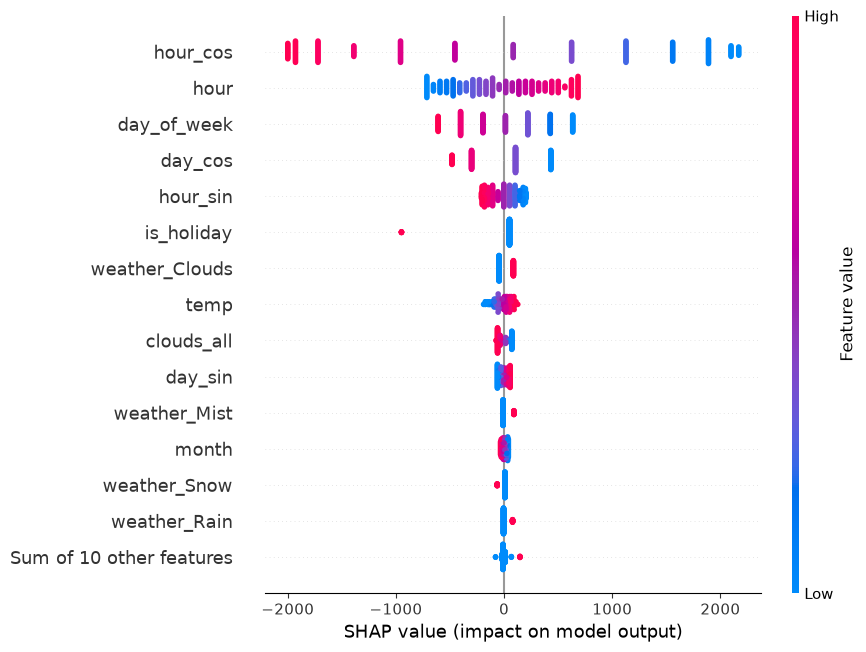

In [16]:
# SHAP summary plot for Linear Regression
shap.plots.beeswarm(shap_values, max_display=15)

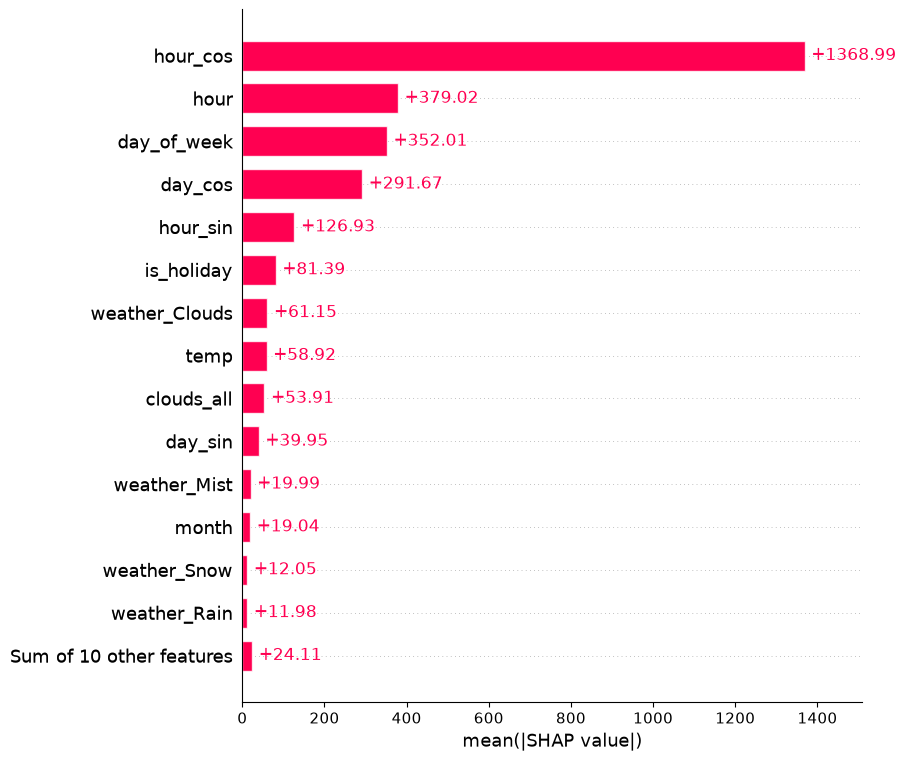

In [17]:
# Global SHAP feature importance
shap.plots.bar(shap_values, max_display=15)

### SHAP Explainability Findings

SHAP analysis was applied to the Linear Regression model using 200 sampled test observations. The results show that temporal features have the greatest influence on predicted traffic volume. In particular, the time-of-day features (`hour`, `hour_sin`, and `hour_cos`) collectively dominate the model, while day-of-week features also have substantial influence.

The SHAP beeswarm plot shows both the magnitude and direction of these effects. For example, higher `hour_cos` values, corresponding broadly to hours nearer midnight, tend to reduce predicted traffic volume, whereas lower values, corresponding more closely to daytime hours, tend to increase predicted volume.

The mean absolute SHAP plot confirms that `hour_cos` has the largest average contribution, followed by `hour`, `day_of_week`, and `day_cos`. Weather-related variables such as temperature, cloud cover, rain, snow, and mist have considerably smaller effects.

Because `hour`, `hour_sin`, and `hour_cos` represent the same underlying time-of-day information in different forms, their SHAP values should be interpreted collectively rather than as independent effects. The same limitation applies to the day-of-week variables.

In [18]:
try:
    import mlflow
    print("MLflow version:", mlflow.__version__)
except ImportError:
    print("MLflow is not installed.")

MLflow version: 3.15.1


In [22]:
## Task 4: MLflow Experiment Tracking

import mlflow
import os

# Store MLflow experiment tracking in a local SQLite database
mlflow_db = os.path.abspath("mlflow.db")
mlflow.set_tracking_uri(f"sqlite:///{mlflow_db}")

# Create/select experiment
mlflow.set_experiment("capstone_part3_traffic_models")

print("MLflow database:", mlflow_db)
print("Experiment: capstone_part3_traffic_models")

2026/09/29 15:04:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/29 15:04:47 INFO mlflow.store.db.utils: Updating database tables
2026/09/29 15:04:54 INFO mlflow.tracking.fluent: Experiment with name 'capstone_part3_traffic_models' does not exist. Creating a new experiment.


MLflow database: /home/7e999635-eb70-4aaa-83b3-b876a4975b50/mlflow.db
Experiment: capstone_part3_traffic_models


In [23]:
# Log Linear Regression experiment

with mlflow.start_run(run_name="Linear_Regression_Traffic_Volume"):

    # Model information
    mlflow.log_param("model_type", "Linear Regression")
    mlflow.log_param("task", "Traffic Volume Prediction")
    mlflow.log_param("n_features", X_train_reg.shape[1])
    mlflow.log_param("training_observations", len(X_train_reg))
    mlflow.log_param("testing_observations", len(X_test_reg))

    # Performance metrics
    mlflow.log_metric("MAE", mae_lin)
    mlflow.log_metric("RMSE", rmse_lin)
    mlflow.log_metric("R2", r2_lin)

    print("Linear Regression experiment logged successfully.")

Linear Regression experiment logged successfully.


In [24]:
# Verify MLflow experiment and logged runs

experiment = mlflow.get_experiment_by_name("capstone_part3_traffic_models")

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

runs[[
    "tags.mlflow.runName",
    "params.model_type",
    "metrics.MAE",
    "metrics.RMSE",
    "metrics.R2"
]]

,tags.mlflow.runName,params.model_type,metrics.MAE,metrics.RMSE,metrics.R2
0,Linear_Regression_Traffic_Volume,Linear Regression,812.735321,1035.360163,0.728856


In [28]:
# Log Random Forest Regression experiment

with mlflow.start_run(run_name="Random_Forest_Traffic_Volume"):

    mlflow.log_param("model_type", "Random Forest Regression")
    mlflow.log_param("task", "Traffic Volume Prediction")
    mlflow.log_param("n_estimators", rf_reg.n_estimators)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("n_features", X_train_reg.shape[1])
    mlflow.log_param("training_observations", len(X_train_reg))
    mlflow.log_param("testing_observations", len(X_test_reg))

    mlflow.log_metric("MAE", mae_rf)
    mlflow.log_metric("RMSE", rmse_rf)
    mlflow.log_metric("R2", r2_rf)

    print("Random Forest Regression experiment logged successfully.")

Random Forest Regression experiment logged successfully.


In [29]:
experiment = mlflow.get_experiment_by_name("capstone_part3_traffic_models")

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

runs[[
    "tags.mlflow.runName",
    "params.model_type",
    "metrics.MAE",
    "metrics.RMSE",
    "metrics.R2"
]]

,tags.mlflow.runName,params.model_type,metrics.MAE,metrics.RMSE,metrics.R2
0,Random_Forest_Traffic_Volume,Random Forest Regression,225.387849,378.749133,0.963716
1,Random_Forest_Traffic_Volume,Random Forest Regression,NaN,NaN,NaN
2,Linear_Regression_Traffic_Volume,Linear Regression,812.735321,1035.360163,0.728856


In [30]:
# Show only completed MLflow regression runs

completed_runs = runs.dropna(
    subset=["metrics.MAE", "metrics.RMSE", "metrics.R2"]
)

completed_runs[[
    "tags.mlflow.runName",
    "params.model_type",
    "metrics.MAE",
    "metrics.RMSE",
    "metrics.R2"
]]

,tags.mlflow.runName,params.model_type,metrics.MAE,metrics.RMSE,metrics.R2
0,Random_Forest_Traffic_Volume,Random Forest Regression,225.387849,378.749133,0.963716
2,Linear_Regression_Traffic_Volume,Linear Regression,812.735321,1035.360163,0.728856


In [31]:
print("nn_model exists:", "nn_model" in globals())
print("mae_nn exists:", "mae_nn" in globals())
print("rmse_nn exists:", "rmse_nn" in globals())
print("r2_nn exists:", "r2_nn" in globals())

nn_model exists: False
mae_nn exists: False
rmse_nn exists: False
r2_nn exists: False


In [32]:
# Log previously completed Neural Network experiment

with mlflow.start_run(run_name="Neural_Network_Traffic_Volume"):

    mlflow.log_param("model_type", "Neural Network")
    mlflow.log_param("task", "Traffic Volume Prediction")
    mlflow.log_param("epochs", 50)
    mlflow.log_param("result_source", "Previously completed notebook run")

    mlflow.log_metric("MAE", 343.8095397949219)
    mlflow.log_metric("RMSE", 510.55495235576745)
    mlflow.log_metric("R2", 0.9340671300888062)

    print("Neural Network experiment logged successfully.")

Neural Network experiment logged successfully.


In [33]:
# Compare completed MLflow traffic-volume experiments

experiment = mlflow.get_experiment_by_name("capstone_part3_traffic_models")

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

completed_runs = runs.dropna(
    subset=["metrics.MAE", "metrics.RMSE", "metrics.R2"]
)

completed_runs[[
    "tags.mlflow.runName",
    "params.model_type",
    "metrics.MAE",
    "metrics.RMSE",
    "metrics.R2"
]]

,tags.mlflow.runName,params.model_type,metrics.MAE,metrics.RMSE,metrics.R2
0,Neural_Network_Traffic_Volume,Neural Network,343.809540,510.554952,0.934067
1,Random_Forest_Traffic_Volume,Random Forest Regression,225.387849,378.749133,0.963716
3,Linear_Regression_Traffic_Volume,Linear Regression,812.735321,1035.360163,0.728856


### Task 4: Advanced AI Technique – MLflow Experiment Tracking

#### Why MLflow was selected
MLflow was selected because this project evaluates several machine-learning models and therefore requires a structured way to record and compare experiments. It also connects directly with the MLOps component of the project by supporting experiment tracking, model comparison and model lifecycle management.

#### How it was implemented
A local MLflow experiment named `capstone_part3_traffic_models` was created using a SQLite tracking database. Separate experiment runs were recorded for Linear Regression, Random Forest Regression and the Neural Network for traffic-volume prediction.

For each model, relevant parameters and common evaluation metrics were logged. The main comparison metrics were Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and R². The completed experiment runs were retrieved from MLflow and displayed in a common comparison table.

The Random Forest Regression achieved the strongest performance of the three models, with MAE of 225.39, RMSE of 378.75 and R² of 0.964. The Neural Network achieved R² of 0.934, while Linear Regression achieved R² of 0.729.

#### Value added
MLflow provides a persistent and structured record of machine-learning experiments instead of relying only on results displayed in individual notebook cells. This improves traceability and makes it easier to compare different modelling approaches using consistent metrics.

It also provides a foundation for later MLOps activities such as model versioning, deployment and monitoring. In this project, the tracked results provide clear evidence of the relative performance of the three traffic-volume prediction models and support the selection of the Random Forest Regression model for the recommendation system.

#### Limitations
MLflow does not improve model accuracy or data quality by itself. Its usefulness depends on experiments being logged consistently with appropriate parameters, metrics and model information.

Incomplete or failed runs can remain in the experiment history and need to be identified or excluded from comparisons. This occurred during development when an incomplete Random Forest run was created before the model and metrics were available.

In addition, the Neural Network metrics were logged retrospectively from a previously completed 50-epoch notebook run rather than being generated during the MLflow run itself. Although the source of these metrics was explicitly recorded, rerunning training directly within an MLflow run would provide stronger experiment reproducibility.

Finally, the current implementation uses local MLflow tracking with a SQLite database. A production implementation would require more robust shared storage, access control, model governance and deployment infrastructure.

## Task 5: Traffic Recommendation System

Because the Metro Interstate Traffic Volume dataset represents a single traffic corridor, the recommendation system focuses on identifying suitable travel times rather than selecting alternative routes.

A hybrid recommendation approach is used. Historical traffic patterns are combined with the trained Random Forest Regression model to identify lower-traffic travel periods. Day type and weather conditions are also considered where appropriate. The system evaluates candidate travel times within a user-specified time window and generates a plain-language recommendation for a suitable travel period.

In [ ]:
# Task 5.1: Historical traffic baseline by day type and hour

# Classify each observation as weekday or weekend
df["day_type"] = df["day_of_week"].apply(
    lambda x: "Weekday" if x < 5 else "Weekend"
)

# Mean historical traffic volume for each hour
historical_hourly = (
    df.groupby(["day_type", "hour"])["traffic_volume"]
      .mean()
      .reset_index()
)

# Show the five lowest-traffic hours for each day type
lowest_hours = (
    historical_hourly
    .sort_values(["day_type", "traffic_volume"])
    .groupby("day_type")
    .head(5)
)

print("Five historically lowest-traffic hours:")
print(lowest_hours.to_string(index=False))

In [35]:
# Task 5.2: Find lower-traffic periods within a practical travel window

def historical_recommendation(day_type, start_hour, end_hour):
    
    candidates = historical_hourly[
        (historical_hourly["day_type"] == day_type) &
        (historical_hourly["hour"] >= start_hour) &
        (historical_hourly["hour"] <= end_hour)
    ].sort_values("traffic_volume")
    
    return candidates.head(3)


# Example: weekday travel between 7 AM and 12 PM
historical_recommendation("Weekday", 7, 12)

,day_type,hour,traffic_volume
10,Weekday,10,4378.419118
11,Weekday,11,4633.419470
12,Weekday,12,4855.382143


In [37]:
# Task 5.3: Check features used by the Random Forest model

print("Random Forest input features:")
for i, feature in enumerate(X_train_reg.columns, start=1):
    print(i, feature)

Random Forest input features:
1 hour
2 day_of_week
3 month
4 hour_sin
5 hour_cos
6 day_sin
7 day_cos
8 is_holiday
9 is_low_visibility
10 temp
11 rain_1h
12 snow_1h
13 clouds_all
14 weather_Clear
15 weather_Clouds
16 weather_Drizzle
17 weather_Fog
18 weather_Haze
19 weather_Mist
20 weather_Rain
21 weather_Smoke
22 weather_Snow
23 weather_Squall
24 weather_Thunderstorm


In [40]:
# Task 5.3: Preference-based filtering

def filter_travel_options(
    data,
    day_type=None,
    day_of_week=None,
    month=None,
    start_hour=None,
    end_hour=None,
    avoid_rain=False,
    avoid_snow=False,
    avoid_low_visibility=False,
    avoid_holidays=False
):
    
    options = data.copy()

    # Apply only the preferences selected by the user
    if day_type is not None:
        options = options[options["day_type"] == day_type]

    if day_of_week is not None:
        options = options[options["day_of_week"] == day_of_week]

    if month is not None:
        options = options[options["month"] == month]

    if start_hour is not None:
        options = options[options["hour"] >= start_hour]

    if end_hour is not None:
        options = options[options["hour"] <= end_hour]

    if avoid_rain:
        options = options[options["rain_1h"] == 0]

    if avoid_snow:
        options = options[options["snow_1h"] == 0]

    if avoid_low_visibility:
        options = options[options["is_low_visibility"] == 0]

    if avoid_holidays:
        options = options[options["is_holiday"] == 0]

    return options


# Test example:
# User wants a weekday journey between 7 AM and 4 PM
# and wants to avoid rain

test_options = filter_travel_options(
    df,
    day_type="Weekday",
    start_hour=7,
    end_hour=16,
    avoid_rain=True
)

print("Number of matching historical observations:", len(test_options))

print("\nFive lower-traffic hours matching the preferences:")

print(
    test_options.groupby("hour")["traffic_volume"]
                .mean()
                .sort_values()
                .head(5)
)

Number of matching historical observations: 13142

Five lower-traffic hours matching the preferences:
hour
10    4379.337500
11    4639.398754
12    4852.940310
13    4858.453312
9     4882.831945
Name: traffic_volume, dtype: float64


In [41]:
# Task 5.4: Use Random Forest predictions for matching travel options

# Use the same 24 features used to train the Random Forest
X_options = test_options[feature_columns].copy()

# Predict traffic volume for every historical observation
# that matches the user's selected preferences
test_options_pred = test_options.copy()
test_options_pred["predicted_traffic"] = rf_reg.predict(X_options)

# Calculate average predicted traffic for each candidate hour
predicted_by_hour = (
    test_options_pred
    .groupby("hour")
    .agg(
        predicted_traffic=("predicted_traffic", "mean"),
        historical_traffic=("traffic_volume", "mean"),
        observations=("traffic_volume", "size")
    )
    .reset_index()
    .sort_values("predicted_traffic")
)

print("Recommended hours based on Random Forest predictions:")
print(predicted_by_hour.head(5).to_string(index=False))

Recommended hours based on Random Forest predictions:
 hour  predicted_traffic  historical_traffic  observations
   10        4378.010618         4379.337500          1360
   11        4636.845257         4639.398754          1284
   12        4850.196589         4852.940310          1290
   13        4856.141453         4858.453312          1253
    9        4882.904625         4882.831945          1321


In [42]:
# Task 5.5: Hybrid Traffic Recommendation System

def recommend_travel_time(
    data,
    model,
    day_type=None,
    day_of_week=None,
    month=None,
    start_hour=None,
    end_hour=None,
    avoid_rain=False,
    avoid_snow=False,
    avoid_low_visibility=False,
    avoid_holidays=False
):
    
    # Apply user-selected preferences
    options = filter_travel_options(
        data,
        day_type=day_type,
        day_of_week=day_of_week,
        month=month,
        start_hour=start_hour,
        end_hour=end_hour,
        avoid_rain=avoid_rain,
        avoid_snow=avoid_snow,
        avoid_low_visibility=avoid_low_visibility,
        avoid_holidays=avoid_holidays
    )
    
    # Check that matching historical observations exist
    if len(options) == 0:
        return "No historical observations match the selected preferences."
    
    # Generate Random Forest traffic predictions
    X_options = options[feature_columns].copy()
    
    options = options.copy()
    options["predicted_traffic"] = model.predict(X_options)
    
    # Compare candidate hours
    hourly_results = (
        options.groupby("hour")
        .agg(
            predicted_traffic=("predicted_traffic", "mean"),
            historical_traffic=("traffic_volume", "mean"),
            observations=("traffic_volume", "size")
        )
        .reset_index()
        .sort_values("predicted_traffic")
    )
    
    # Best candidate hour
    best = hourly_results.iloc[0]
    best_hour = int(best["hour"])
    predicted_volume = best["predicted_traffic"]
    
    # Build description of selected preferences
    preferences = []
    
    if day_type is not None:
        preferences.append(day_type.lower())
        
    if avoid_rain:
        preferences.append("avoiding rain")
        
    if avoid_snow:
        preferences.append("avoiding snow")
        
    if avoid_low_visibility:
        preferences.append("avoiding low-visibility conditions")
        
    if avoid_holidays:
        preferences.append("avoiding holidays")
    
    preference_text = ", ".join(preferences)
    
    if preference_text:
        preference_text = " for a " + preference_text + " journey"
    
    # Plain-language recommendation
    recommendation = (
        f"Recommendation: Consider travelling around {best_hour:02d}:00"
        f"{preference_text}. "
        f"The Random Forest model predicts an average traffic volume of "
        f"approximately {predicted_volume:,.0f} vehicles at this time, "
        f"the lowest among the candidate hours meeting the selected preferences."
    )
    
    print(recommendation)
    
    return hourly_results


# Example recommendation:
recommendation_results = recommend_travel_time(
    df,
    rf_reg,
    day_type="Weekday",
    start_hour=7,
    end_hour=16,
    avoid_rain=True
)

Recommendation: Consider travelling around 10:00 for a weekday, avoiding rain journey. The Random Forest model predicts an average traffic volume of approximately 4,378 vehicles at this time, the lowest among the candidate hours meeting the selected preferences.


In [43]:
import ipywidgets as widgets

print("ipywidgets is available.")

ipywidgets is available.


In [44]:
# Task 5.6: Interactive Traffic Recommendation System

import ipywidgets as widgets
from IPython.display import display, clear_output

# ---------- User controls ----------

day_type_widget = widgets.Dropdown(
    options=["Any", "Weekday", "Weekend"],
    value="Any",
    description="Day type:"
)

day_widget = widgets.Dropdown(
    options=[
        ("Any", None),
        ("Monday", 0),
        ("Tuesday", 1),
        ("Wednesday", 2),
        ("Thursday", 3),
        ("Friday", 4),
        ("Saturday", 5),
        ("Sunday", 6)
    ],
    value=None,
    description="Day:"
)

month_widget = widgets.Dropdown(
    options=[
        ("Any", None),
        ("January", 1), ("February", 2), ("March", 3),
        ("April", 4), ("May", 5), ("June", 6),
        ("July", 7), ("August", 8), ("September", 9),
        ("October", 10), ("November", 11), ("December", 12)
    ],
    value=None,
    description="Month:"
)

hour_options = [(f"{h:02d}:00", h) for h in range(24)]

start_widget = widgets.Dropdown(
    options=hour_options,
    value=7,
    description="Earliest:"
)

end_widget = widgets.Dropdown(
    options=hour_options,
    value=16,
    description="Latest:"
)

rain_widget = widgets.Checkbox(
    value=False,
    description="Avoid rain"
)

snow_widget = widgets.Checkbox(
    value=False,
    description="Avoid snow"
)

visibility_widget = widgets.Checkbox(
    value=False,
    description="Avoid low visibility"
)

holiday_widget = widgets.Checkbox(
    value=False,
    description="Avoid holidays"
)

recommend_button = widgets.Button(
    description="Get Recommendation",
    button_style="success"
)

output = widgets.Output()


# ---------- Recommendation action ----------

def get_recommendation(button):
    
    with output:
        clear_output()

        # Validate travel-start range
        if start_widget.value > end_widget.value:
            print(
                "Please select an earliest travel start time "
                "that is before the latest travel start time."
            )
            return

        selected_day_type = (
            None if day_type_widget.value == "Any"
            else day_type_widget.value
        )

        # Apply selected preferences
        options = filter_travel_options(
            df,
            day_type=selected_day_type,
            day_of_week=day_widget.value,
            month=month_widget.value,
            start_hour=start_widget.value,
            end_hour=end_widget.value,
            avoid_rain=rain_widget.value,
            avoid_snow=snow_widget.value,
            avoid_low_visibility=visibility_widget.value,
            avoid_holidays=holiday_widget.value
        )

        if len(options) == 0:
            print(
                "No historical observations match these preferences. "
                "Try relaxing one or more selections."
            )
            return

        # Random Forest predictions
        X_options = options[feature_columns].copy()

        options = options.copy()
        options["predicted_traffic"] = rf_reg.predict(X_options)

        # Rank candidate travel start times
        hourly_results = (
            options.groupby("hour")
            .agg(
                predicted_traffic=("predicted_traffic", "mean"),
                historical_traffic=("traffic_volume", "mean"),
                observations=("traffic_volume", "size")
            )
            .reset_index()
            .sort_values("predicted_traffic")
        )

        best = hourly_results.iloc[0]

        best_hour = int(best["hour"])
        predicted = best["predicted_traffic"]
        historical = best["historical_traffic"]

        print("TRAFFIC TRAVEL RECOMMENDATION")
        print("--------------------------------")
        print(f"Recommended travel start time: {best_hour:02d}:00")
        print(f"Predicted traffic volume: {predicted:,.0f} vehicles")
        print(f"Historical average: {historical:,.0f} vehicles")
        print(f"Historical observations used: {int(best['observations']):,}")
        print()
        print(
            f"Within your selected start-time range of "
            f"{start_widget.value:02d}:00–{end_widget.value:02d}:00, "
            f"{best_hour:02d}:00 has the lowest average predicted "
            f"traffic among the conditions matching your preferences."
        )

        print("\nOther lower-traffic start times:")
        
        display(
            hourly_results.head(5).rename(
                columns={
                    "hour": "Start hour",
                    "predicted_traffic": "Predicted traffic",
                    "historical_traffic": "Historical traffic",
                    "observations": "Observations"
                }
            )
        )


recommend_button.on_click(get_recommendation)


# ---------- Display interface ----------

title = widgets.HTML(
    "<h3>Traffic Travel Recommendation System</h3>"
    "<p>Select only the preferences that matter to you. "
    "Unselected conditions remain unrestricted.</p>"
)

time_labels = widgets.HTML(
    "<b>Preferred travel start-time range</b>"
)

avoid_label = widgets.HTML("<b>Conditions to avoid</b>")

display(
    title,
    day_type_widget,
    day_widget,
    month_widget,
    time_labels,
    widgets.HBox([
        widgets.VBox([
            widgets.HTML("Earliest travel start time"),
            start_widget
        ]),
        widgets.VBox([
            widgets.HTML("Latest travel start time"),
            end_widget
        ])
    ]),
    avoid_label,
    rain_widget,
    snow_widget,
    visibility_widget,
    holiday_widget,
    recommend_button,
    output
)

HTML(value='<h3>Traffic Travel Recommendation System</h3><p>Select only the preferences that matter to you. Un…

Dropdown(description='Day type:', options=('Any', 'Weekday', 'Weekend'), value='Any')

Dropdown(description='Day:', options=(('Any', None), ('Monday', 0), ('Tuesday', 1), ('Wednesday', 2), ('Thursd…

Dropdown(description='Month:', options=(('Any', None), ('January', 1), ('February', 2), ('March', 3), ('April'…

HTML(value='<b>Preferred travel start-time range</b>')

...

Checkbox(value=False, description='Avoid snow')

Checkbox(value=False, description='Avoid low visibility')

Checkbox(value=False, description='Avoid holidays')

Button(button_style='success', description='Get Recommendation', style=ButtonStyle())

Output()

Interactive Recommendation Interface

The recommendation system was also implemented as an interactive ipywidgets interface, allowing users to select day type, travel-time range, and weather-related conditions to avoid. The interface was successfully tested and generated travel-time recommendations based on the trained model and historical traffic patterns.

Because Jupyter widget state is session-dependent, the interactive controls may display a “model not found” message when the saved notebook is reopened in a new session. The successful interface and recommendation output are shown in the accompanying screenshot.
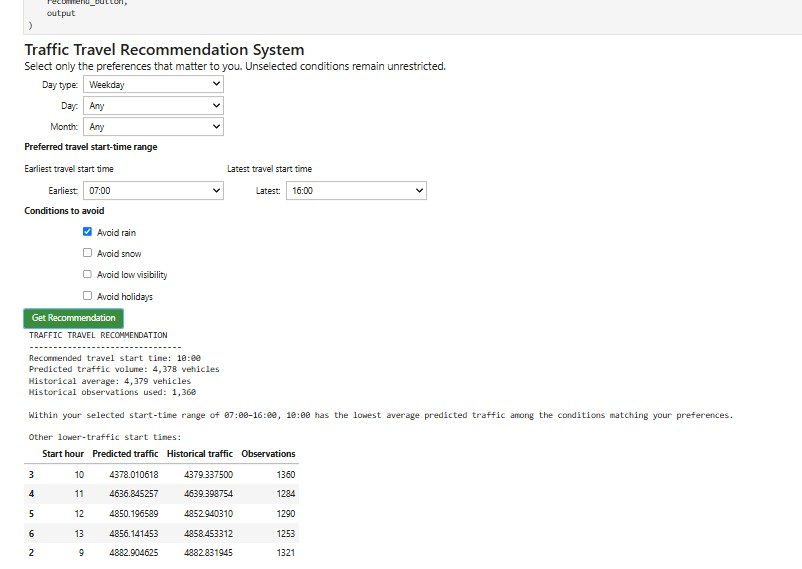

### Task 5 Summary

A hybrid traffic recommendation system was developed for the I-94 westbound corridor. Because the dataset contains only one corridor, the system recommends suitable travel start times rather than alternative routes.

Users can optionally specify day type, day of week, month, earliest and latest travel start times, and conditions to avoid such as rain, snow, low visibility, and holidays. Conditions that are not selected remain unrestricted.

The system first filters historical observations according to the user's preferences. The trained Random Forest Regression model is then applied to the matching observations, and candidate start times are ranked by their average predicted traffic volume. The system returns the recommended start time, predicted traffic volume, historical average traffic volume, number of supporting observations, and several alternative lower-traffic start times.

This hybrid approach combines historical traffic patterns with machine-learning predictions while allowing users to apply only the travel constraints that matter to them. More restrictive preferences may result in fewer matching historical observations, so recommendations based on small samples should be interpreted with greater caution.

In [ ]:
## Task 6: MLOps and Deployment Simulation

This section simulates how the traffic prediction solution could progress from model experimentation to deployment and ongoing monitoring.

### 6.1 Model Versioning

Model versions are documented to provide traceability between different modelling approaches and their performance. Each model family begins at version 1 because the Linear Regression, Random Forest Regression and Neural Network represent different model types rather than successive versions of the same model.

In [45]:
# Task 6.1: Model versioning summary

model_versions = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression",
        "Neural Network"
    ],
    "Version": [
        "v1",
        "v1",
        "v1"
    ],
    "MAE": [
        mae_lin,
        mae_rf,
        343.8095397949219
    ],
    "RMSE": [
        rmse_lin,
        rmse_rf,
        510.55495235576745
    ],
    "R2": [
        r2_lin,
        r2_rf,
        0.9340671300888062
    ],
    "Status": [
        "Baseline",
        "Selected for deployment simulation",
        "Alternative model"
    ]
})

model_versions

,Model,Version,MAE,RMSE,R2,Status
0,Linear Regression,v1,812.735321,1035.360163,0.728856,Baseline
1,Random Forest Regression,v1,225.387849,378.749133,0.963716,Selected for deployment simulation
2,Neural Network,v1,343.809540,510.554952,0.934067,Alternative model


### 6.2 Experiment Tracking

MLflow was used to track the traffic-volume prediction experiments. The experiment `capstone_part3_traffic_models` contains separate runs for Linear Regression, Random Forest Regression and the Neural Network.

For each model, relevant parameters and performance metrics were recorded. Common evaluation metrics included MAE, RMSE and R², allowing the models to be compared consistently.

The MLflow experiment results demonstrated that Random Forest Regression provided the strongest predictive performance and it was therefore selected as version 1 of the Random Forest model for the deployment simulation.

The model versioning table above complements the MLflow experiment history by documenting the role and version of each model used in the project.

In [46]:
with mlflow.start_run(run_name="Random_Forest_v1_Deployment_Record"):

    # Model identification
    mlflow.log_param("model_type", "Random Forest Regression")
    mlflow.log_param("model_version", "v1")
    mlflow.log_param("purpose", "Deployment simulation")

    # Important model parameters
    mlflow.log_param("n_estimators", rf_reg.n_estimators)
    mlflow.log_param("random_state", 42)

    # Performance of the selected model
    mlflow.log_metric("MAE", mae_rf)
    mlflow.log_metric("RMSE", rmse_rf)
    mlflow.log_metric("R2", r2_rf)

    # Additional version metadata
    mlflow.set_tag("deployment_status", "Selected for deployment simulation")
    mlflow.set_tag("model_family", "Random Forest Regression")

    print("Random Forest v1 deployment record logged successfully.")

Random Forest v1 deployment record logged successfully.


In [47]:
# Verify Random Forest v1 record in MLflow

experiment = mlflow.get_experiment_by_name("capstone_part3_traffic_models")

version_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

version_runs[[
    "tags.mlflow.runName",
    "params.model_type",
    "params.model_version",
    "params.purpose",
    "metrics.MAE",
    "metrics.RMSE",
    "metrics.R2"
]].head()

,tags.mlflow.runName,params.model_type,params.model_version,params.purpose,metrics.MAE,metrics.RMSE,metrics.R2
0,Random_Forest_v1_Deployment_Record,Random Forest Regression,v1,Deployment simulation,225.387849,378.749133,0.963716
1,Neural_Network_Traffic_Volume,Neural Network,NaN,NaN,343.809540,510.554952,0.934067
2,Random_Forest_Traffic_Volume,Random Forest Regression,NaN,NaN,225.387849,378.749133,0.963716
3,Random_Forest_Traffic_Volume,Random Forest Regression,NaN,NaN,NaN,NaN,NaN
4,Linear_Regression_Traffic_Volume,Linear Regression,NaN,NaN,812.735321,1035.360163,0.728856


In [48]:
# Task 6.2: Record Linear Regression v1 and Neural Network v1 in MLflow

# Linear Regression v1
with mlflow.start_run(run_name="Linear_Regression_v1_Model_Record"):

    mlflow.log_param("model_type", "Linear Regression")
    mlflow.log_param("model_version", "v1")
    mlflow.log_param("purpose", "Baseline model")

    mlflow.log_metric("MAE", mae_lin)
    mlflow.log_metric("RMSE", rmse_lin)
    mlflow.log_metric("R2", r2_lin)

    mlflow.set_tag("model_family", "Linear Regression")
    mlflow.set_tag("deployment_status", "Baseline")

    print("Linear Regression v1 record logged successfully.")


# Neural Network v1
with mlflow.start_run(run_name="Neural_Network_v1_Model_Record"):

    mlflow.log_param("model_type", "Neural Network")
    mlflow.log_param("model_version", "v1")
    mlflow.log_param("purpose", "Alternative model")
    mlflow.log_param("epochs", 50)
    mlflow.log_param(
        "result_source",
        "Previously completed notebook run"
    )

    mlflow.log_metric("MAE", 343.8095397949219)
    mlflow.log_metric("RMSE", 510.55495235576745)
    mlflow.log_metric("R2", 0.9340671300888062)

    mlflow.set_tag("model_family", "Neural Network")
    mlflow.set_tag("deployment_status", "Alternative model")

    print("Neural Network v1 record logged successfully.")

Linear Regression v1 record logged successfully.
Neural Network v1 record logged successfully.


In [49]:
# Verify MLflow model version records

experiment = mlflow.get_experiment_by_name("capstone_part3_traffic_models")

version_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

version_records = version_runs[
    version_runs["params.model_version"].notna()
]

version_records[[
    "tags.mlflow.runName",
    "params.model_type",
    "params.model_version",
    "params.purpose",
    "metrics.MAE",
    "metrics.RMSE",
    "metrics.R2"
]]

,tags.mlflow.runName,params.model_type,params.model_version,params.purpose,metrics.MAE,metrics.RMSE,metrics.R2
0,Neural_Network_v1_Model_Record,Neural Network,v1,Alternative model,343.809540,510.554952,0.934067
1,Linear_Regression_v1_Model_Record,Linear Regression,v1,Baseline model,812.735321,1035.360163,0.728856
2,Random_Forest_v1_Deployment_Record,Random Forest Regression,v1,Deployment simulation,225.387849,378.749133,0.963716


In [50]:
import flask
print("Flask version:", flask.__version__)

Flask version: 3.1.2


/tmp/ipykernel_531/1179009207.py:2: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print("Flask version:", flask.__version__)


### 6.3 Deployment Simulation

A Flask API mock-up is used to demonstrate how Random Forest Regression v1 could be served as a prediction service.

The API accepts user-friendly traffic and weather inputs, converts them into the engineered feature format required by the trained model, and returns a predicted traffic volume. This separates the model's internal feature requirements from the interface presented to an external application.

In [51]:
# Task 6.3: Flask API deployment mock-up for Random Forest v1

from flask import Flask, request, jsonify
import pandas as pd

app = Flask(__name__)

@app.route("/predict", methods=["POST"])
def predict_traffic():
    
    # Receive input data
    input_data = request.get_json()
    
    try:
        # Convert received values into a DataFrame
        input_df = pd.DataFrame([input_data])
        
        # Ensure features are in exactly the same order
        # as those used to train the Random Forest
        input_df = input_df[feature_columns]
        
        # Generate prediction
        prediction = rf_reg.predict(input_df)[0]
        
        # Return prediction as JSON
        return jsonify({
            "model": "Random Forest Regression",
            "version": "v1",
            "predicted_traffic_volume": round(float(prediction), 2)
        })
    
    except Exception as e:
        return jsonify({
            "error": str(e)
        }), 400


print("Flask prediction API created successfully.")
print("Endpoint: POST /predict")

Flask prediction API created successfully.
Endpoint: POST /predict


In [52]:
# Test the Flask prediction API using one observation

# Take one real observation from the regression test set
sample_input = X_test_reg.iloc[0].to_dict()

# Flask test client simulates an external application calling the API
with app.test_client() as client:
    
    response = client.post(
        "/predict",
        json=sample_input
    )
    
    print("API status code:", response.status_code)
    print("API response:")
    print(response.get_json())

API status code: 200
API response:
{'model': 'Random Forest Regression', 'predicted_traffic_volume': 5618.19, 'version': 'v1'}


#### Deployment Test

The Flask deployment mock-up successfully accepted a test observation through the `/predict` endpoint and returned a traffic-volume prediction from Random Forest Regression v1. The API returned HTTP status code 200, confirming that the request was processed successfully.

For this simulation, the API receives the engineered feature set required by the trained model. In a production system, preprocessing and feature engineering would normally be incorporated into the deployment pipeline so that external applications could submit simpler user-facing inputs.


### 6.4 Model Monitoring

A deployed model should be monitored because its predictive performance may deteriorate when real-world traffic patterns change over time.

No new post-deployment traffic data are available for this project, so actual model drift cannot be measured. To simulate a normal monitoring scenario, a subset of the existing test data is evaluated using the deployed Random Forest v1 model.

The original Random Forest test RMSE is used as the baseline. The RMSE for the monitoring subset is compared with this baseline to demonstrate how prediction-error monitoring could be performed in a deployed system. This simulation demonstrates the monitoring process and should not be interpreted as evidence of actual real-world drift.

In [54]:
# Task 6.4: Simulate prediction-error monitoring

import logging
import numpy as np
from sklearn.metrics import mean_squared_error

logger = logging.getLogger(__name__)

# Baseline performance from the original Random Forest test results
baseline_rmse = rmse_rf

# Simulate a later monitoring period using the last 2,000 test observations
monitor_size = min(2000, len(X_test_reg))

X_monitor = X_test_reg.iloc[-monitor_size:]
y_monitor = y_test_reg.iloc[-monitor_size:]

logger.info(
    "Monitoring batch prepared with %d observations.",
    monitor_size
)

# Generate predictions using Random Forest v1
monitor_predictions = rf_reg.predict(X_monitor)

# Calculate monitoring RMSE
monitor_rmse = np.sqrt(
    mean_squared_error(y_monitor, monitor_predictions)
)

# Calculate percentage change from baseline
rmse_change_pct = (
    (monitor_rmse - baseline_rmse) / baseline_rmse
) * 100

logger.info(
    "Prediction-error monitoring completed. "
    "Baseline RMSE=%.2f, Monitoring RMSE=%.2f, Change=%.2f%%",
    baseline_rmse,
    monitor_rmse,
    rmse_change_pct
)

# Direct monitoring result for the notebook user
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Monitoring RMSE: {monitor_rmse:.2f}")
print(f"Change in RMSE: {rmse_change_pct:.2f}%")

Baseline RMSE: 378.75
Monitoring RMSE: 378.33
Change in RMSE: -0.11%


In [ ]:
#### Monitoring Result

The simulated normal monitoring scenario produced an RMSE of 378.33 compared with the baseline RMSE of 378.75, a change of -0.11%. This indicates essentially no deterioration in prediction error within the existing test-data subset.

However, because no new post-deployment data are available, this result demonstrates the monitoring process only and does not establish that the model has remained stable under future real-world traffic conditions.

### 6.5 Monitoring Alert

A simple alerting mechanism was implemented to translate the monitoring result into an operational status.

For this simulation, an increase in RMSE of more than 20% above the baseline is defined as requiring investigation. This threshold is used for demonstration purposes and would need to be validated against operational requirements and acceptable prediction error in a real deployment.

The monitoring system reports:

- **PASS / Normal** when the RMSE increase is 20% or less.
- Because no new post-deployment data are available, the dashboard includes both the existing normal monitoring scenario and an artificial drift scenario to demonstrate how the alerting mechanism would respond to deterioration in model performance.

In [55]:
# Task 6.5: Interactive Model Monitoring Dashboard

import ipywidgets as widgets
from IPython.display import display
import logging

logger = logging.getLogger(__name__)

alert_threshold_pct = 20.0

# Artificial RMSE used only to demonstrate an alert
simulated_drift_rmse = baseline_rmse * 1.30

scenario_widget = widgets.Dropdown(
    options=[
        ("Normal monitoring scenario", "normal"),
        ("Simulated drift scenario", "drift")
    ],
    value="normal",
    description="Scenario:"
)

dashboard_output = widgets.HTML()


def update_monitoring_dashboard(change):
    
    if scenario_widget.value == "normal":
        current_rmse = monitor_rmse
        scenario_name = "Normal monitoring scenario"
        
    else:
        current_rmse = simulated_drift_rmse
        scenario_name = "Artificial drift simulation"
    
    change_pct = (
        (current_rmse - baseline_rmse) / baseline_rmse
    ) * 100
    
    if change_pct > alert_threshold_pct:
        status = "ALERT / Requires investigation"
        
        logger.warning(
            "Monitoring alert triggered: RMSE increased by %.2f%%.",
            change_pct
        )
        
    else:
        status = "PASS / Normal"
        
        logger.info(
            "Monitoring status normal: RMSE change %.2f%%.",
            change_pct
        )
    
    dashboard_output.value = f"""
    <h3>Model Monitoring Dashboard</h3>
    <table style="font-size:15px">
        <tr><td><b>Model</b></td>
            <td>Random Forest Regression v1</td></tr>
        <tr><td><b>Scenario</b></td>
            <td>{scenario_name}</td></tr>
        <tr><td><b>Baseline RMSE</b></td>
            <td>{baseline_rmse:.2f}</td></tr>
        <tr><td><b>Current RMSE</b></td>
            <td>{current_rmse:.2f}</td></tr>
        <tr><td><b>RMSE change</b></td>
            <td>{change_pct:.2f}%</td></tr>
        <tr><td><b>Alert threshold</b></td>
            <td>{alert_threshold_pct:.0f}% increase</td></tr>
    </table>

    <h3>Status: {status}</h3>
    """


scenario_widget.observe(
    update_monitoring_dashboard,
    names="value"
)

# Initialise dashboard
update_monitoring_dashboard(None)

display(
    scenario_widget,
    dashboard_output
)

Dropdown(description='Scenario:', options=(('Normal monitoring scenario', 'normal'), ('Simulated drift scenari…

HTML(value='\n    <h3>Model Monitoring Dashboard</h3>\n    <table style="font-size:15px">\n        <tr><td><b>…

#### Alerting Result

The dashboard successfully distinguishes between normal and potentially deteriorating model performance. The normal monitoring simulation produced an RMSE change of -0.11% and therefore returned **PASS / Normal**.

To test the alert mechanism, an artificial drift scenario was created with an RMSE 30% above the baseline. Because this exceeded the predefined 20% threshold, the dashboard returned **ALERT / Requires investigation** and generated a warning log.

The artificial scenario is used only to demonstrate the monitoring and alerting mechanism and does not represent observed real-world model drift.

The monitoring and alerting mechanism was also implemented as an interactive dashboard. Because Jupyter widget state is session-dependent, the interactive controls may display a “model not found” message when the saved notebook is reopened in a new session. The successfully tested dashboard is shown below. It demonstrates the artificial drift scenario, in which a 30% increase in RMSE exceeds the 20% alert threshold and produces ALERT / Requires investigation.
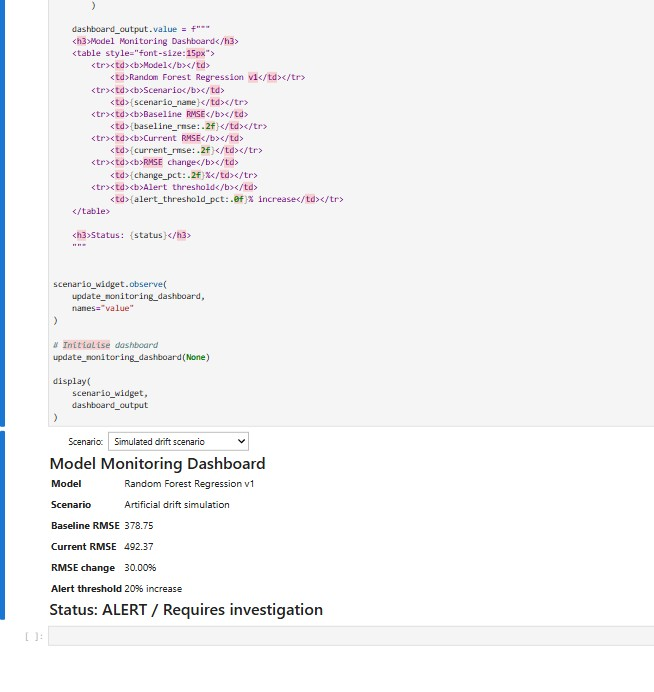    

## Task 7: Responsible and Sustainable AI

### 7.1 Bias and Fairness

#### Sampling and Coverage Limitations

The Metro Interstate Traffic Volume dataset represents hourly westbound traffic on a single section of I-94 in the Minneapolis–St Paul area. It therefore does not represent the entire road network, alternative routes, eastbound traffic, other geographic regions or other cities. Results from this project should not be assumed to generalise to other roads or populations without further validation.

The dataset also has uneven temporal coverage. The 2012 data represent only part of the year, while data-quality investigation identified repeated observations and missing periods in 2014. Some weather categories are uncommon and therefore contain relatively few observations. Models may consequently be less reliable under rare conditions than under frequently observed traffic and weather conditions.

The travel recommendation system introduces an additional coverage consideration. When users select multiple constraints, such as a particular month, day type, time range and weather exclusions, the number of matching historical observations may become small. Recommendations based on small samples should therefore be interpreted with greater caution.


#### Proxy Accident-Risk Label

No real accident dataset was provided for this project. A proxy accident-risk label was therefore created from the available congestion and weather information, as specified for the capstone task.

An observation was classified as high risk when **High or Severe congestion occurred together with severe or low-visibility weather conditions**.

Severe weather was defined as:

- Thunderstorm
- Squall
- Snow

Low-visibility weather was defined as:

- Mist
- Fog
- Haze
- Smoke

The resulting proxy classified approximately **11.3% of observations as high risk** and **88.7% as non-high-risk**, resulting in an imbalanced classification target.

This proxy does not represent an observed accident and must not be interpreted as actual accident probability. It encodes an assumed relationship between congestion, adverse weather and accident risk. Actual accidents may depend on many factors that are not available in this dataset, including driver behaviour, road design, vehicle condition, construction activity, road-surface conditions and unexpected incidents.

There is also a risk of **target leakage or circularity**. The proxy target is constructed from congestion and weather conditions, while weather-related variables used to define or closely represent those conditions are also included among the classification model predictors. The classifier may therefore learn the rules used to construct the proxy rather than discover independent predictors of real accidents.

Consequently, the very high classification performance obtained in this project should be interpreted as performance in predicting the defined proxy label, not as evidence of equivalent performance in predicting actual accidents.

For a real-world safety application, validated accident or incident records should replace the proxy label, and the model should be retrained and independently evaluated before deployment.


#### Uneven Distribution of Model Errors

Overall metrics such as MAE, RMSE, R², accuracy, precision, recall, F1-score and ROC AUC provide useful summaries of model performance but can conceal differences across subgroups of the data.

Traffic-volume prediction errors may vary by hour of day, weekday versus weekend, month or season, holiday status and weather condition. Common conditions contribute more observations to the overall evaluation metrics, while unusual conditions may be represented by relatively small samples.

For example, severe weather, snow, low-visibility conditions and holidays may have fewer observations than ordinary traffic conditions. Good overall model performance therefore does not guarantee equally reliable predictions under every condition.

Before real-world deployment, errors should be evaluated separately across relevant temporal and environmental subgroups. Sample size should also be considered when interpreting subgroup performance. Particular attention should be given to uncommon but operationally important conditions where inaccurate predictions could have greater consequences.


### 7.2 Governance and Sustainability

#### Governance and Human Oversight

The models developed in this project should be treated as **decision-support tools rather than autonomous traffic-management or road-safety systems**.

Before real-world deployment, the complete system should undergo validation using current, representative and independently verified data. Appropriate governance should include:

- Data-quality checks before new data enter the modelling pipeline.
- Documented datasets, preprocessing steps and feature definitions.
- Reproducible experiment tracking and model versioning.
- Defined performance and monitoring thresholds.
- Monitoring for deterioration in prediction performance and changes in input data.
- Logging of important processing, deployment and monitoring events.
- Investigation procedures when monitoring alerts are triggered.
- Human review before consequential model changes or safety-related decisions.

The MLflow experiment tracking and model-versioning process demonstrated in this project provides a foundation for model governance by recording model parameters, metrics, experiments and versions.

The limitations of the proxy accident-risk label should be clearly disclosed to users and decision-makers. A proxy-based classification model should not be represented as an actual accident-prediction system without validation against genuine accident or incident data.


#### Model Updating and Continuous Improvement

A production mobility-AI system should provide a controlled mechanism for incorporating new traffic data. As new observations become available, they can be added to the historical dataset and used for **periodic model retraining**. This would allow the model to adapt to longer-term changes in traffic patterns, road usage, weather relationships and travel behaviour.

The Random Forest model used in this project is not an online-learning model and does not automatically update itself when new observations arrive. Instead, new data would be incorporated through a controlled retraining pipeline.

A retrained model should be evaluated against the currently deployed model using consistent performance metrics and subgroup checks before being approved as a new model version. For example, the currently deployed **Random Forest v1** could remain in use while a newly trained **Random Forest v2** is evaluated. A newer version should not automatically replace the existing model merely because it was trained on newer data.

Model monitoring can help determine when retraining may be appropriate. Sustained deterioration in prediction error or meaningful changes in feature distributions could trigger investigation and possible retraining. MLflow could then record the new experiment, parameters, metrics and model version, maintaining traceability throughout the model lifecycle.

More advanced systems could use incremental or online-learning approaches in which models are updated more frequently as new observations arrive. However, these approaches require stronger automated data-quality controls, monitoring and governance to prevent poor-quality or unusual incoming data from degrading model performance.


#### Sustainability and Resource Considerations

Different modelling approaches have different computational and environmental costs. Linear Regression requires relatively little computation and provides a useful baseline, whereas Random Forest models and Neural Networks generally require greater computational resources.

In this project, Random Forest Regression achieved stronger traffic-volume prediction performance than the Neural Network:

- Random Forest Regression: R² approximately **0.964**
- Neural Network: R² approximately **0.934**
- Linear Regression: R² approximately **0.729**

The Random Forest was therefore selected for the recommendation system and deployment simulation. In this project, the more computationally intensive Neural Network did not provide better predictive performance than the Random Forest. This illustrates that greater model complexity does not necessarily produce greater practical value.

Resource use can be reduced by avoiding unnecessary model complexity, avoiding repeated training when an existing validated model remains suitable, limiting hyperparameter searches to meaningful ranges and retraining models when justified by new data or monitoring results rather than automatically.

For a larger mobility-AI system, sustainability assessment should consider the computational and storage requirements of data processing, model training, inference, experiment tracking, model versioning and ongoing monitoring alongside the operational benefits delivered by the system.


### Task 7 Conclusion

Responsible deployment of mobility AI requires more than high model-performance metrics. Data coverage, proxy-target limitations, uneven error distribution, governance, monitoring, human oversight and computational resources all affect whether a model is suitable for real-world use.

In this project, the traffic-volume models and recommendation system demonstrate how machine learning can support travel-timing decisions, while the accident-risk classification demonstrates the limitations of using a constructed proxy when real outcome data are unavailable.

A real deployment would require current and representative data, genuine accident data for safety-related modelling, subgroup validation, ongoing monitoring and a controlled process for retraining, versioning and approving updated models.